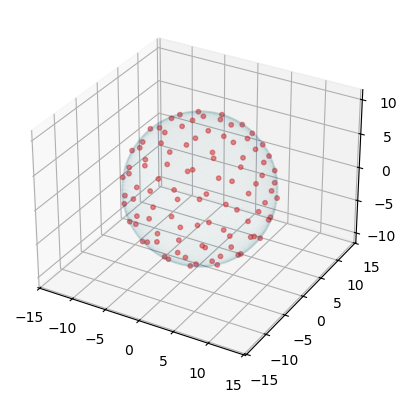

In [1]:
import numpy as np

import multi_aster_spindle as mas

import matplotlib.pyplot as plt
import argparse
import os

# ceph = '/mnt/home/ealca/ceph/'
# home = '/mnt/home/ealca/'
ceph = '/Users/emrealca/home/'
home = '/Users/emrealca/home/'

mesh_density = 6
num_motors = 100
cell_radius = 10 # um

# sloan_60 = np.load(f'{home}multi-aster/sloane_cache/sloane_{60}.npy') * cell_radius
# sloan_60 = sloan_60[sloan_60[:,0] < 0]
# sloan_120 = np.load(f'{home}multi-aster/sloane_cache/sloane_{120}.npy') * cell_radius
# sloan_120 = sloan_120[sloan_120[:,0] > 0]
# asymmetric_motor_lattice = np.vstack([sloan_120, sloan_60])  

sloan_100 = np.load(f'{home}multi-aster/sloane_cache/sloane_{num_motors}.npy') * cell_radius
trimesh = np.load(f'{home}multi-aster/trimesh_cache/sphere_{mesh_density}_subdivs_1_radius.npy') * cell_radius

pull_lattice = sloan_100
push_lattice = trimesh

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = push_lattice[:,0]
ys = push_lattice[:,1]
zs = push_lattice[:,2]

ax.scatter(xs, ys, zs, alpha=0.05, s=0.01, c='tab:blue')

xs_p = pull_lattice[:,0]
ys_p = pull_lattice[:,1]
zs_p = pull_lattice[:,2]

ax.scatter(xs_p, ys_p, zs_p, alpha=0.5, s=10, c='tab:red')

ax.axis('equal')

plt.show()

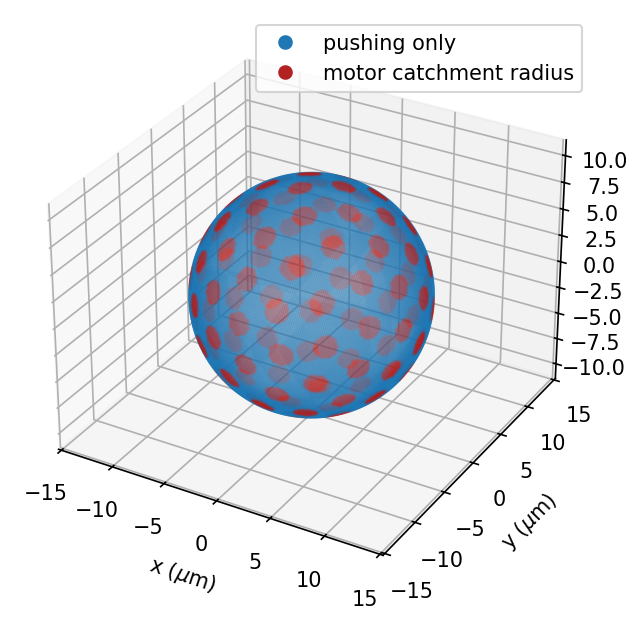

In [2]:
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D

motor_radius = 1.0  # um, same catchment radius used in Spindle.sample_spindle_update via push_to_pull

# same construction as Spindle.__init__: nearest pull site for every push site,
# kept only if it falls within motor_radius of that pull site
tree = cKDTree(pull_lattice)
distances, nearest_pull_idx = tree.query(push_lattice, k=1)
within_catchment = distances <= motor_radius

push_colors = np.where(within_catchment, 'firebrick', 'tab:blue')

fig = plt.figure(figsize=(7,5), dpi=150)
ax = fig.add_subplot(111, projection='3d')

ax.scatter(push_lattice[:, 0], push_lattice[:, 1], push_lattice[:, 2],
           alpha=0.2, s=0.5, c=push_colors)

# ax.scatter(pull_lattice[:, 0], pull_lattice[:, 1], pull_lattice[:, 2],
#            alpha=0.9, s=2, c='k')
ax.set_xlabel(r'x ($\mu$m)')
ax.set_ylabel(r'y ($\mu$m)')
ax.set_zlabel(r'z ($\mu$m)', labelpad=12)
ax.axis('equal')

# scatter() with a per-point color array doesn't produce a sensible legend entry,
# so build one manually from proxy circle markers instead
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='tab:blue', label='pushing only'),
    Line2D([0], [0], marker='o', linestyle='', color='firebrick', label=f'motor catchment radius'),
    # Line2D([0], [0], marker='o', linestyle='', color='k', label='motor (pull) site'),
]
ax.legend(handles=legend_handles)

# fig.tight_layout()
plt.show()